# Hierarchical Clustering — Theory

## 1. Definition
Hierarchical Clustering is an **unsupervised learning** method that builds a hierarchy of clusters without requiring the number of clusters to be specified in advance.  
It produces a **dendrogram** — a tree-like diagram that shows the sequence of merges or splits.

Two main approaches:
- **Agglomerative (Bottom-Up):**  
  Start with each data point as its own cluster, and iteratively merge the closest clusters until only one cluster remains.
- **Divisive (Top-Down):**  
  Start with all data points in a single cluster and recursively split clusters.

---

## 2. Algorithm (Agglomerative Clustering)
**Input:** Dataset with $ n $ points, distance metric $ d(\cdot, \cdot) $, linkage criterion.  
**Output:** Hierarchical tree (dendrogram) and optional cluster labels.

**Steps:**
1. **Initialization:** Assign each data point to its own cluster.
2. **Compute Distance Matrix:** Calculate pairwise distances between all clusters using the chosen linkage method.
3. **Merge Closest Clusters:** Identify the two clusters with the smallest distance and merge them.
4. **Update Distance Matrix:** Recalculate distances between the new cluster and all remaining clusters.
5. **Repeat Steps 3–4** until only one cluster remains.
6. **(Optional)**: Cut the dendrogram at a chosen height to form \( k \) clusters.

---

## 3. Linkage Criteria & Equations
The **linkage criterion** defines how the distance between two clusters is calculated from distances between their individual points.

Let:
- $ C_i, C_j $ be two clusters.
- $ x_a \in C_i, x_b \in C_j $ be data points.
- $ d(x_a, x_b) $ be the distance between two points (commonly Euclidean distance):

$$
d(x_a, x_b) = \sqrt{\sum_{m=1}^M \left( x_a^{(m)} - x_b^{(m)} \right)^2}
$$

### Common Linkage Methods:

1. **Single Linkage:**
$$
D(C_i, C_j) = \min_{x_a \in C_i, \; x_b \in C_j} \; d(x_a, x_b)
$$
(Nearest points between clusters)

2. **Complete Linkage:**
$$
D(C_i, C_j) = \max_{x_a \in C_i, \; x_b \in C_j} \; d(x_a, x_b)
$$
(Farthest points between clusters)

3. **Average Linkage:**
$$
D(C_i, C_j) = \frac{1}{|C_i| \cdot |C_j|} \sum_{x_a \in C_i} \sum_{x_b \in C_j} d(x_a, x_b)
$$
(Average pairwise distance)

4. **Ward’s Method:**
Merges clusters to minimize the increase in total **within-cluster variance**:
$$
D(C_i, C_j) = \frac{|C_i| \cdot |C_j|}{|C_i| + |C_j|} \cdot \| \mu_i - \mu_j \|^2
$$
where $ \mu_i $ is the centroid of $ C_i $.

---

## 4. Dendrogram
A dendrogram is a binary tree diagram where:
- Leaves represent individual points.
- Internal nodes represent cluster merges.
- The height of a node indicates the distance at which clusters were merged.

**Cutting the dendrogram** at a certain height determines the final number of clusters.

---

## 5. Advantages & Disadvantages

**Advantages:**
- No need to pre-specify number of clusters.
- Produces interpretable dendrograms.
- Can capture complex cluster shapes.

**Disadvantages:**
- Computationally expensive for large datasets ($ O(n^3) $ time complexity in naive implementations).
- Sensitive to noise and outliers.
- Choice of linkage and distance metric affects results.

---
<!-- 
**References:**
- Jain, A. K., & Dubes, R. C. (1988). *Algorithms for Clustering Data*. Prentice-Hall.
- Rokach, L., & Maimon, O. (2005). *Clustering Methods*. In *Data Mining and Knowledge Discovery Handbook* (pp. 321–352).
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*. -->


## Import Required Libraries

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

##  Create a Synthetic Dataset
We'll use `make_blobs` to create 2D data for easy visualization.

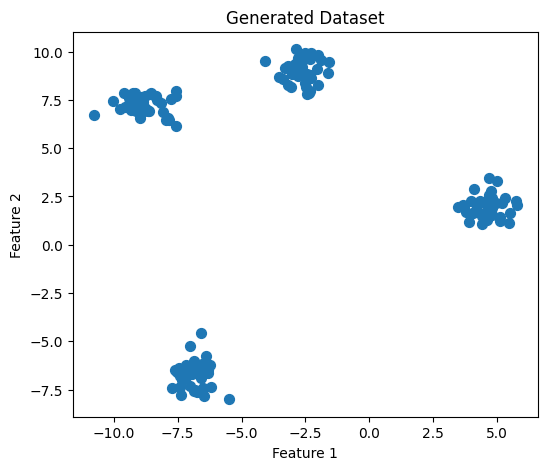

In [19]:
# Generate synthetic data
X, y_true = make_blobs(n_samples=150, centers=4, cluster_std=0.60, random_state=42)

# Visualize the generated data
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Generated Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Apply Agglomerative Clustering
We will specify:
- `n_clusters=4` because we know there are 4 groups in the dataset.
- `linkage='ward'` which minimizes variance within clusters.
- `affinity='euclidean'` for distance measurement.

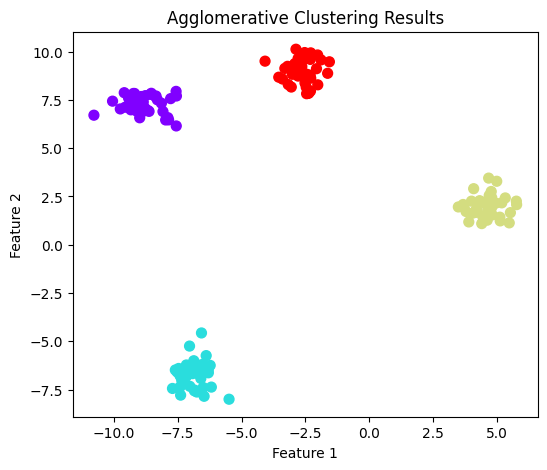

In [20]:
# Apply Agglomerative Clustering
agg_clustering = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
cluster_labels = agg_clustering.fit_predict(X)

# Visualize the clustered data
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=cluster_labels, cmap='rainbow', s=50)
plt.title("Agglomerative Clustering Results")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## Plot the Dendrogram
A dendrogram shows the hierarchical relationships between clusters.
We will use SciPy's `linkage` and `dendrogram` functions.

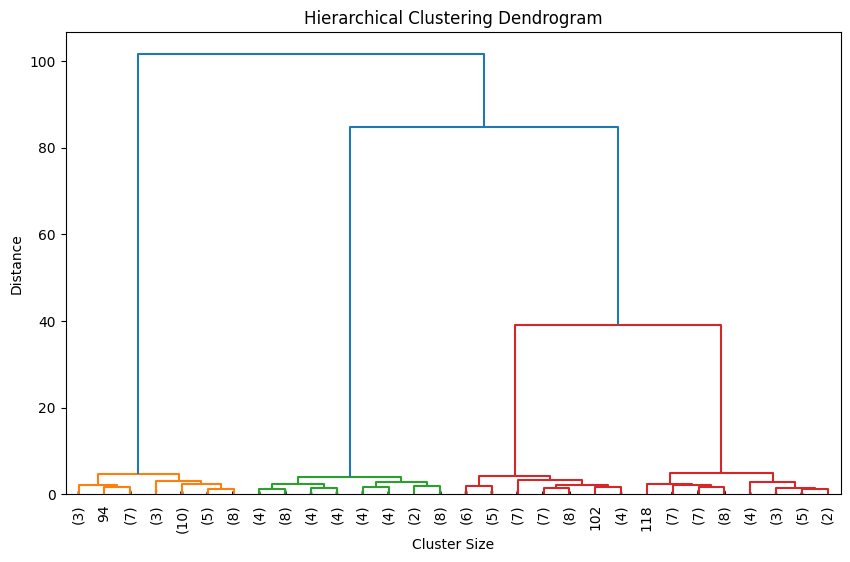

In [21]:
Z = linkage(X, method='ward')

# Plot dendrogram
plt.figure(figsize=(10, 6))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster Size")
plt.ylabel("Distance")
plt.show()

## Updated Dataset for Better Linkage Comparison
We'll use `make_moons` with noise, which creates non-spherical clusters.
This will highlight differences between linkage methods in the dendrogram.

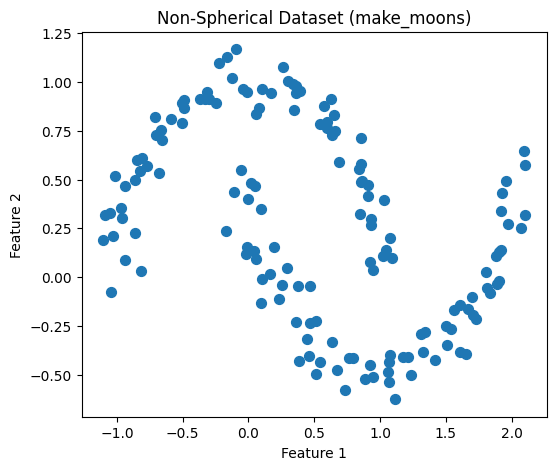

In [23]:
from sklearn.datasets import make_moons

# Generate non-spherical dataset
X, _ = make_moons(n_samples=150, noise=0.08, random_state=42)

# Visualize dataset
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Non-Spherical Dataset (make_moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


 ## Linkage Comparison — Dendrograms

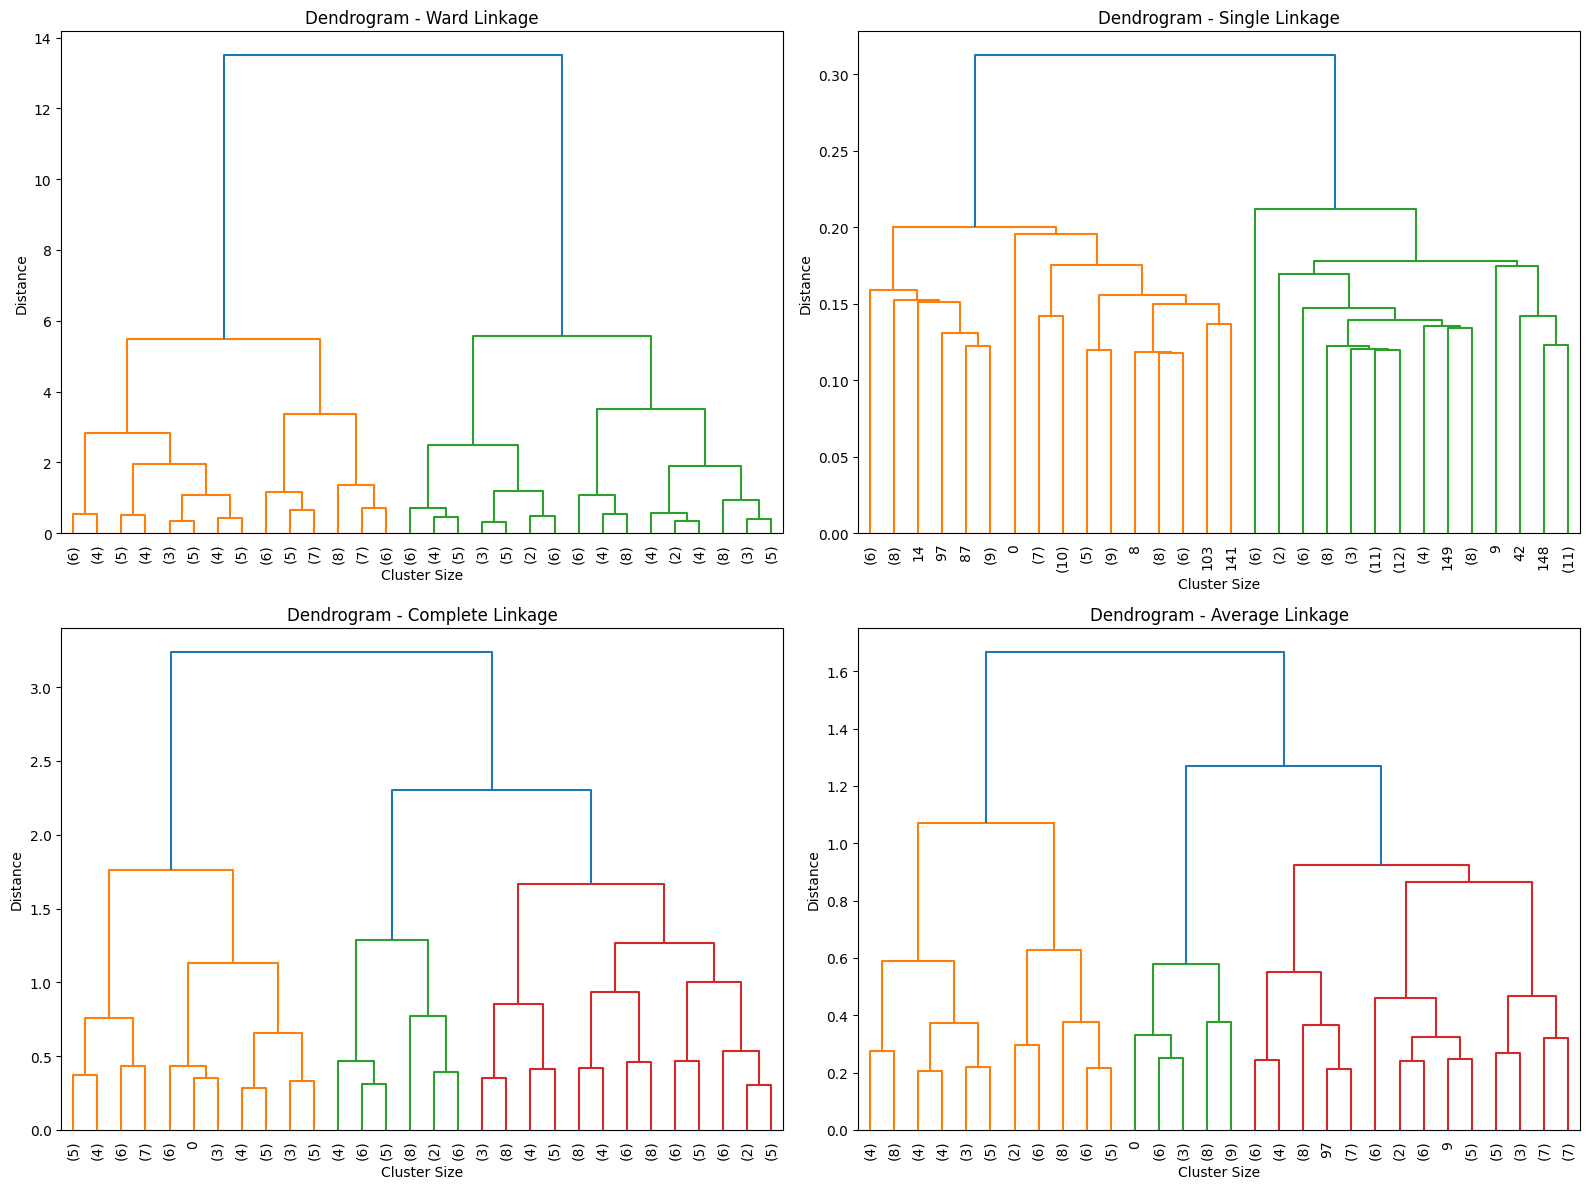

In [24]:
linkage_methods = ["ward", "single", "complete", "average"]

plt.figure(figsize=(16, 12))
for i, method in enumerate(linkage_methods, 1):
    Z = linkage(X, method=method)
    plt.subplot(2, 2, i)
    dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90., leaf_font_size=10.)
    plt.title(f"Dendrogram - {method.capitalize()} Linkage")
    plt.xlabel("Cluster Size")
    plt.ylabel("Distance")

plt.tight_layout()
plt.show()